In [1]:
import sys
sys.path.append("..")

from pathlib import Path
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from collections import Counter
from PIL import Image
import numpy as np

DATA_DIR = Path("../data/raw/plantvillage/PlantVillage")

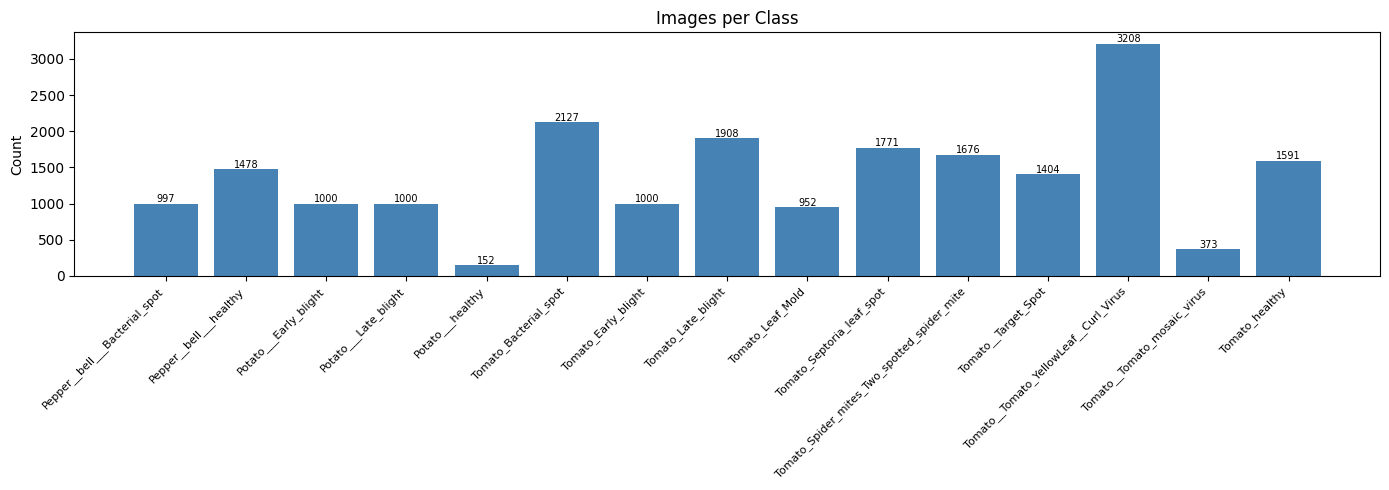

Total images : 20637
Min per class: 152 (Potato___healthy)
Max per class: 3208 (Tomato__Tomato_YellowLeaf__Curl_Virus)


In [2]:
# Class distribution
classes = sorted([
    d.name for d in DATA_DIR.iterdir()
    if d.is_dir() and len(list(d.glob("*.jpg")) + list(d.glob("*.JPG")) + list(d.glob("*.png"))) > 0
])

counts = []
for cls in classes:
    cls_dir = DATA_DIR / cls
    n = len(list(cls_dir.glob("*.jpg")) + list(cls_dir.glob("*.JPG")) + list(cls_dir.glob("*.png")))
    counts.append(n)

plt.figure(figsize=(14, 5))
bars = plt.bar(classes, counts, color="steelblue")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.title("Images per Class")
plt.ylabel("Count")
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, str(count), ha="center", fontsize=7)
plt.tight_layout()
plt.show()

print(f"Total images : {sum(counts)}")
print(f"Min per class: {min(counts)} ({classes[counts.index(min(counts))]})")
print(f"Max per class: {max(counts)} ({classes[counts.index(max(counts))]})")

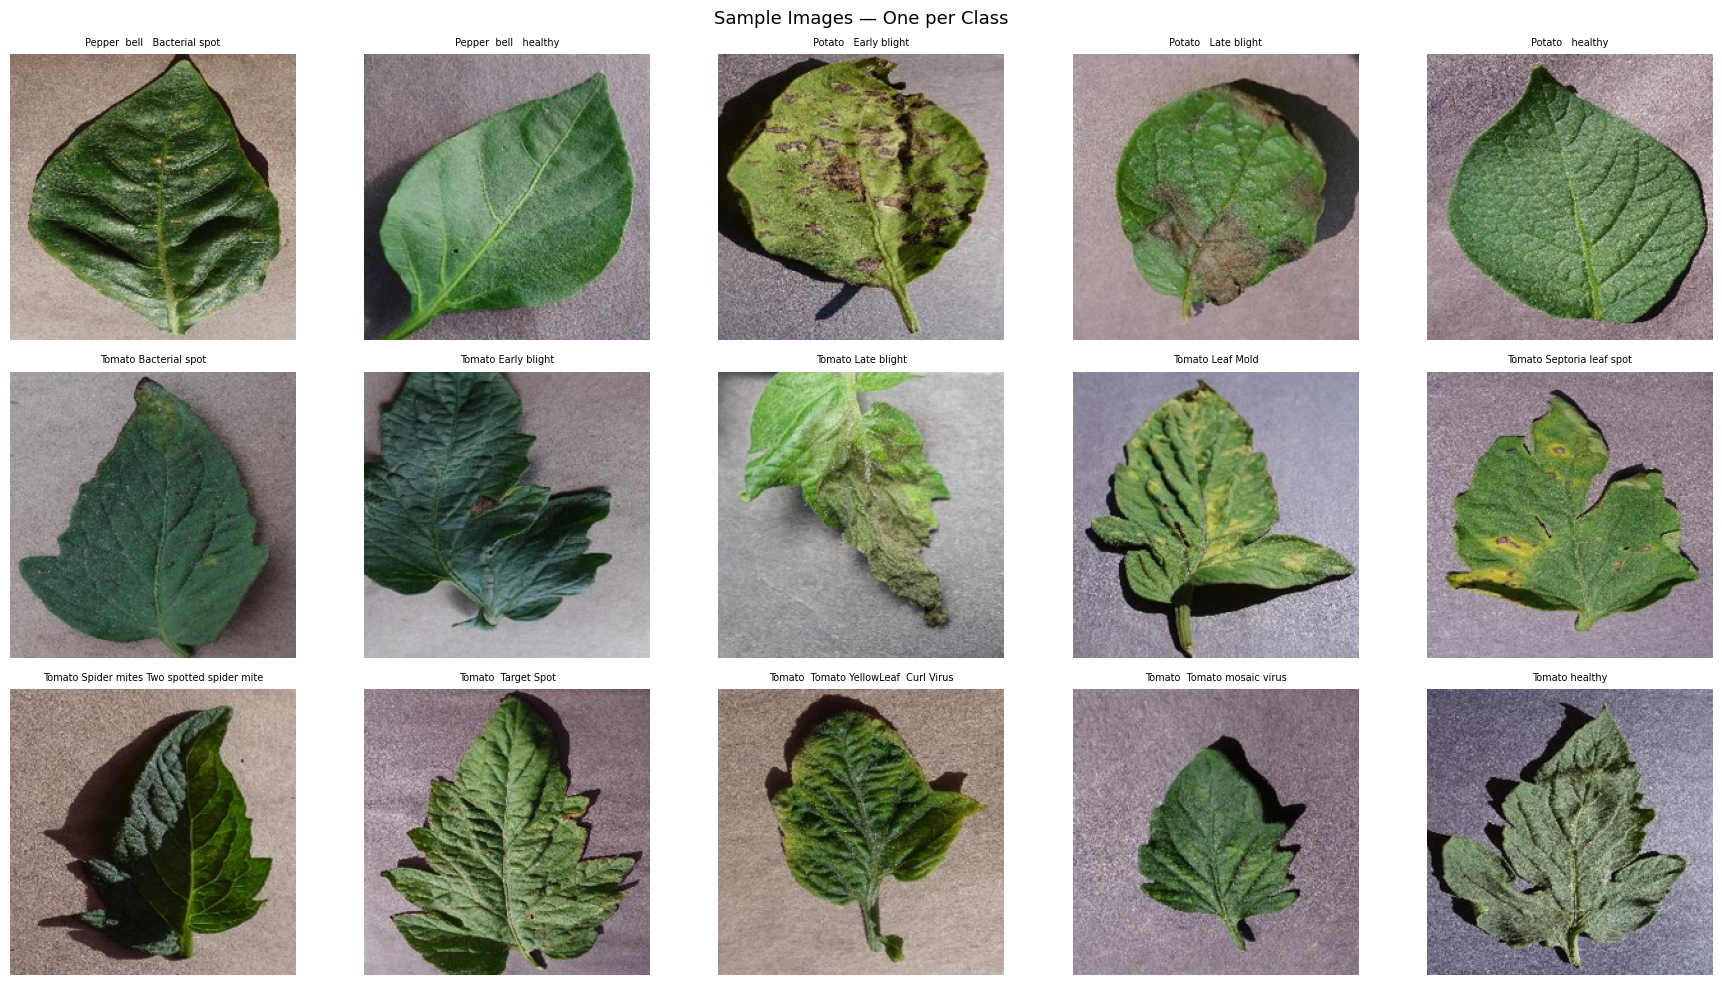

In [3]:
# Sample images from each class
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for idx, cls in enumerate(classes):
    cls_dir = DATA_DIR / cls
    images = list(cls_dir.glob("*.jpg")) + list(cls_dir.glob("*.JPG"))
    img = Image.open(random.choice(images)).resize((224, 224))
    axes[idx].imshow(img)
    axes[idx].set_title(cls.replace("_", " "), fontsize=7)
    axes[idx].axis("off")

plt.suptitle("Sample Images — One per Class", fontsize=13)
plt.tight_layout()
plt.show()


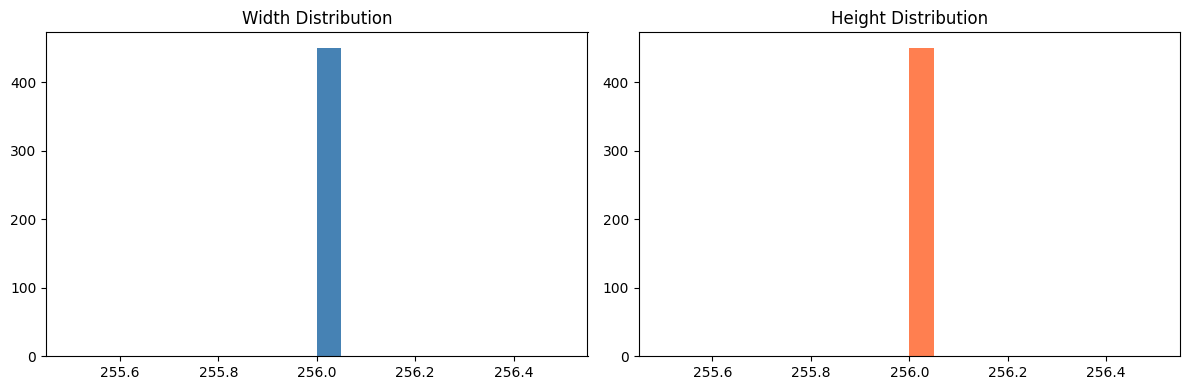

Width  — min: 256, max: 256, mean: 256
Height — min: 256, max: 256, mean: 256


In [4]:
# Image size distribution
widths, heights = [], []

for cls in classes:
    cls_dir = DATA_DIR / cls
    images = list(cls_dir.glob("*.jpg")) + list(cls_dir.glob("*.JPG"))
    for img_path in random.sample(images, min(30, len(images))):
        w, h = Image.open(img_path).size
        widths.append(w)
        heights.append(h)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=20, color="steelblue")
axes[0].set_title("Width Distribution")
axes[1].hist(heights, bins=20, color="coral")
axes[1].set_title("Height Distribution")
plt.tight_layout()
plt.show()

print(f"Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")

In [5]:
# Class imbalance ratio
max_count = max(counts)
print("Imbalance ratio (max/each):\n")
for cls, count in sorted(zip(classes, counts), key=lambda x: x[1]):
    ratio = max_count / count
    bar = "█" * int(ratio * 3)
    print(f"{ratio:5.1f}x  {bar:20s}  {cls}")

Imbalance ratio (max/each):

 21.1x  ███████████████████████████████████████████████████████████████  Potato___healthy
  8.6x  █████████████████████████  Tomato__Tomato_mosaic_virus
  3.4x  ██████████            Tomato_Leaf_Mold
  3.2x  █████████             Pepper__bell___Bacterial_spot
  3.2x  █████████             Potato___Early_blight
  3.2x  █████████             Potato___Late_blight
  3.2x  █████████             Tomato_Early_blight
  2.3x  ██████                Tomato__Target_Spot
  2.2x  ██████                Pepper__bell___healthy
  2.0x  ██████                Tomato_healthy
  1.9x  █████                 Tomato_Spider_mites_Two_spotted_spider_mite
  1.8x  █████                 Tomato_Septoria_leaf_spot
  1.7x  █████                 Tomato_Late_blight
  1.5x  ████                  Tomato_Bacterial_spot
  1.0x  ███                   Tomato__Tomato_YellowLeaf__Curl_Virus
